# Pharmacy AI Project — Safia Model
## MobileNetV2 + LSTM

This notebook follows the same pipeline style as the ResNet50 + LSTM notebook, but replaces the image model with **MobileNetV2**.

### Pipeline
1. Load final preprocessed dataset.
2. Build MobileNetV2 image branch.
3. Build LSTM text branch.
4. Fuse image + text features.
5. Train and evaluate the model.
6. Save the model.
7. Connect prediction with safety and interaction JSON files.


## 1. Extract Dataset ZIP

Upload the final data ZIP file to Colab first.


In [1]:
import os
import zipfile

zip_files = [f for f in os.listdir("/content") if f.endswith(".zip")]
print("ZIP files:", zip_files)

if len(zip_files) == 0:
    raise FileNotFoundError("Please upload the final_data ZIP file first.")

zip_path = os.path.join("/content", zip_files[0])
extract_path = "/content/dataset"

print("Using ZIP:", zip_path)

if not zipfile.is_zipfile(zip_path):
    raise ValueError("Uploaded file is not a valid ZIP. Please re-upload the correct final_data ZIP file.")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Done Extracting ✅")


ZIP files: ['final_data-20260512T164045Z-3-001.zip']
Using ZIP: /content/final_data-20260512T164045Z-3-001.zip
Done Extracting ✅


## 2. Locate Dataset Folder

In [2]:
DATA_PATH = None

for root, dirs, files in os.walk(extract_path):
    if "X_img_train.npy" in files:
        DATA_PATH = root
        break

if DATA_PATH is None:
    raise FileNotFoundError("Could not find X_img_train.npy inside extracted files.")

print("DATA_PATH:", DATA_PATH)
print(os.listdir(DATA_PATH))


DATA_PATH: /content/dataset/final_data
['tokenizer.pkl', 'y_train.npy', 'X_img_train.npy', 'idx_train.npy', 'idx_val.npy', 'y_test.npy', 'X_img_val.npy', 'idx_test.npy', 'X_txt_tfidf_test.npy', 'X_txt_tfidf_val.npy', 'X_txt_seq_val.npy', 'X_txt_seq_test.npy', 'label_classes.json', 'tfidf_vectorizer.pkl', 'y_val.npy', 'X_img_test.npy', 'X_txt_seq_train.npy', 'X_txt_tfidf_train.npy']


## 3. Import Libraries

In [3]:
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LSTM,
    Embedding,
    GlobalAveragePooling2D,
    Concatenate
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 4. Load Preprocessed Data

This notebook does not repeat preprocessing.  
It uses the output files generated from the preprocessing notebook.


In [4]:
# Image data
X_img_train = np.load(os.path.join(DATA_PATH, "X_img_train.npy")).astype("float32")
X_img_val   = np.load(os.path.join(DATA_PATH, "X_img_val.npy")).astype("float32")
X_img_test  = np.load(os.path.join(DATA_PATH, "X_img_test.npy")).astype("float32")

# Text sequence data
X_txt_train = np.load(os.path.join(DATA_PATH, "X_txt_seq_train.npy")).astype("int32")
X_txt_val   = np.load(os.path.join(DATA_PATH, "X_txt_seq_val.npy")).astype("int32")
X_txt_test  = np.load(os.path.join(DATA_PATH, "X_txt_seq_test.npy")).astype("int32")

# Labels
y_train = np.load(os.path.join(DATA_PATH, "y_train.npy")).astype("int32")
y_val   = np.load(os.path.join(DATA_PATH, "y_val.npy")).astype("int32")
y_test  = np.load(os.path.join(DATA_PATH, "y_test.npy")).astype("int32")

# Label names
with open(os.path.join(DATA_PATH, "label_classes.json"), "r") as f:
    label_classes = json.load(f)

print("Image Train Shape:", X_img_train.shape)
print("Text Train Shape:", X_txt_train.shape)
print("Labels Shape:", y_train.shape)
print("Classes:", label_classes)


Image Train Shape: (637, 224, 224, 3)
Text Train Shape: (637, 100)
Labels Shape: (637,)
Classes: {'0': 'amoxicillin', '1': 'aspirin', '2': 'ibuprofen', '3': 'insulin', '4': 'omeprazole', '5': 'paracetamol'}


## 5. Prepare Labels and Tokenizer Information

In [5]:
num_classes = len(label_classes)
class_names = [label_classes[str(i)] for i in range(num_classes)]

# One-hot labels, same style as the ResNet50 + LSTM notebook
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

# Load tokenizer to get real vocabulary size
tokenizer_path = os.path.join(DATA_PATH, "tokenizer.pkl")

if os.path.exists(tokenizer_path):
    with open(tokenizer_path, "rb") as f:
        tokenizer = pickle.load(f)
    vocab_size = len(tokenizer.word_index) + 1
else:
    tokenizer = None
    vocab_size = int(np.max(X_txt_train)) + 1

max_token_id = int(max(np.max(X_txt_train), np.max(X_txt_val), np.max(X_txt_test)))
vocab_size = max(vocab_size, max_token_id + 1)
max_len = X_txt_train.shape[1]

print("y_train_cat:", y_train_cat.shape)
print("Classes:", class_names)
print("Max Length:", max_len)
print("Vocabulary Size:", vocab_size)


y_train_cat: (637, 6)
Classes: ['amoxicillin', 'aspirin', 'ibuprofen', 'insulin', 'omeprazole', 'paracetamol']
Max Length: 100
Vocabulary Size: 406


## 6. Image Branch — MobileNetV2

In [6]:
tf.keras.backend.clear_session()

# Image Input
image_input = Input(shape=(224, 224, 3), name="image_input")

# MobileNetV2 Base
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=image_input
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

# Image Features
x = base_model.output
x = GlobalAveragePooling2D(name="image_global_avg_pool")(x)
x = Dense(256, activation="relu", name="image_dense")(x)
x = Dropout(0.3, name="image_dropout")(x)

image_features = x


/tmp/ipykernel_4042/2420671662.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 7. Text Branch — LSTM

In [7]:
# Text Input
text_input = Input(shape=(max_len,), name="text_input")

# Embedding
txt = Embedding(
    input_dim=vocab_size,
    output_dim=128,
    name="text_embedding"
)(text_input)

# LSTM
txt = LSTM(128, name="text_lstm")(txt)
txt = Dense(128, activation="relu", name="text_dense")(txt)
txt = Dropout(0.3, name="text_dropout")(txt)

text_features = txt


## 8. Fusion Layer

In [8]:
# Merge image and text features
combined = Concatenate(name="fusion_concatenate")([image_features, text_features])

# Dense Layers
z = Dense(128, activation="relu", name="fusion_dense")(combined)
z = Dropout(0.3, name="fusion_dropout")(z)

output = Dense(num_classes, activation="softmax", name="drug_prediction")(z)


## 9. Build and Compile Model

In [9]:
model = Model(
    inputs=[image_input, text_input],
    outputs=output,
    name="Safia_MobileNetV2_LSTM_Model"
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "Safia_MobileNetV2_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,836,038 (10.82 MB)

 Trainable params: 578,054 (2.21 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10. Train Model

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "/content/best_safia_mobilenetv2_lstm.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    [X_img_train, X_txt_train],
    y_train_cat,
    validation_data=([X_img_val, X_txt_val], y_val_cat),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 743ms/step - accuracy: 0.3646 - loss: 1.5983
Epoch 1: val_loss improved from None to 0.57500, saving model to /content/best_safia_mobilenetv2_lstm.keras

Epoch 1: finished saving model to /content/best_safia_mobilenetv2_lstm.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 49s 961ms/step - accuracy: 0.4992 - loss: 1.2664 - val_accuracy: 0.7750 - val_loss: 0.5750
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.7553 - loss: 0.7679
Epoch 2: val_loss improved from 0.57500 to 0.18672, saving model to /content/best_safia_mobilenetv2_lstm.keras

Epoch 2: finished saving model to /content/best_safia_mobilenetv2_lstm.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 790ms/step - accuracy: 0.7943 - loss: 0.6128 - val_accuracy: 0.9625 - val_loss: 0.1867
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.8891 - loss: 0.3327
Epoch 3: val_loss did not improve from 0.18672
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 705ms/step - accuracy: 0.8760 - loss: 0.3928 - val_ac

## 11. Evaluate Model

In [11]:
test_loss, test_accuracy = model.evaluate(
    [X_img_test, X_txt_test],
    y_test_cat
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 832ms/step - accuracy: 0.9000 - loss: 0.2781
Test Accuracy: 0.8999999761581421
Test Loss: 0.2781267762184143


## 12. Classification Report and Confusion Matrix

In [12]:
y_pred_probs = model.predict([X_img_test, X_txt_test])
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step
Classification Report:
              precision    recall  f1-score   support

 amoxicillin       0.92      0.86      0.89        14
     aspirin       0.73      0.80      0.76        10
   ibuprofen       0.86      0.86      0.86        14
     insulin       1.00      0.92      0.96        12
  omeprazole       1.00      1.00      1.00        12
 paracetamol       0.89      0.94      0.92        18

    accuracy                           0.90        80
   macro avg       0.90      0.90      0.90        80
weighted avg       0.90      0.90      0.90        80

Confusion Matrix:
[[12  0  0  0  0  2]
 [ 0  8  2  0  0  0]
 [ 0  2 12  0  0  0]
 [ 0  1  0 11  0  0]
 [ 0  0  0  0 12  0]
 [ 1  0  0  0  0 17]]


## 13. Accuracy and Loss Curves

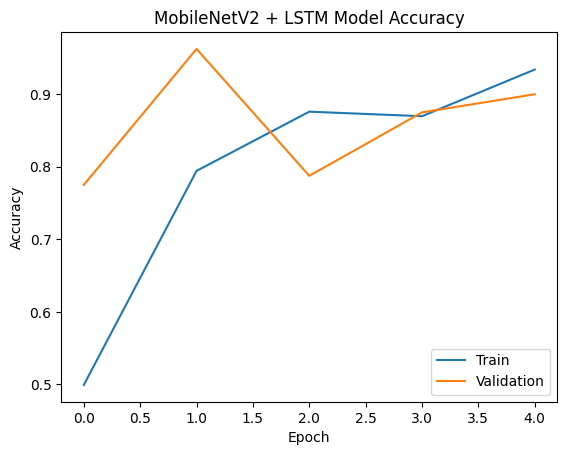

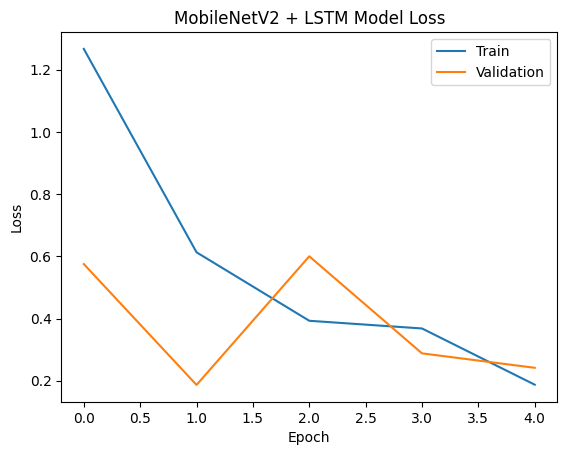

In [13]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("MobileNetV2 + LSTM Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("MobileNetV2 + LSTM Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()


## 14. Save Model

In [14]:
model.save("/content/Safia_MobileNetV2_LSTM_Model.keras")
print("Model Saved Successfully ✅")


Model Saved Successfully ✅


## 15. Single Prediction Example

In [15]:
sample_index = 0

sample_image = X_img_test[sample_index]
sample_text = X_txt_test[sample_index]

prediction = model.predict([
    np.expand_dims(sample_image, axis=0),
    np.expand_dims(sample_text, axis=0)
])

predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted Drug:", label_classes[str(predicted_class)])
print("True Drug:", label_classes[str(int(y_test[sample_index]))])
print("Confidence:", round(float(confidence) * 100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Predicted Drug: ibuprofen
True Drug: ibuprofen
Confidence: 83.9 %


## 16. Show Prediction Image

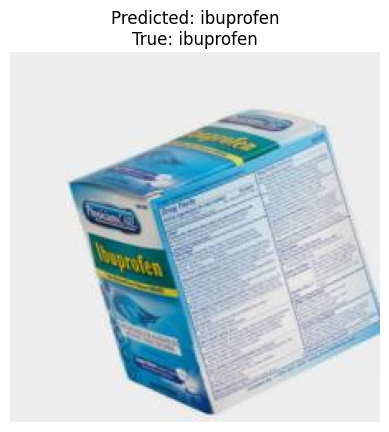

In [16]:
plt.imshow(sample_image)
plt.title(
    f"Predicted: {label_classes[str(predicted_class)]}\nTrue: {label_classes[str(int(y_test[sample_index]))]}"
)
plt.axis("off")
plt.show()


## 17. Test One Sample from Each Drug

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


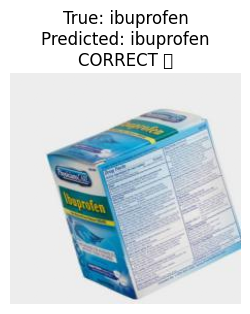

True Drug: ibuprofen
Predicted: ibuprofen
Confidence: 83.9 %
Status: CORRECT ✅
------------------------------


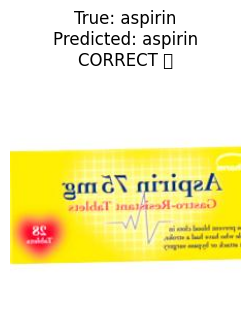

True Drug: aspirin
Predicted: aspirin
Confidence: 76.37 %
Status: CORRECT ✅
------------------------------


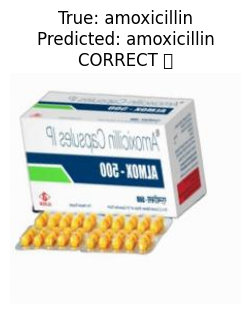

True Drug: amoxicillin
Predicted: amoxicillin
Confidence: 96.21 %
Status: CORRECT ✅
------------------------------


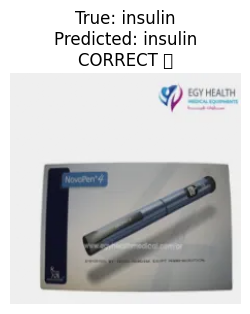

True Drug: insulin
Predicted: insulin
Confidence: 99.97 %
Status: CORRECT ✅
------------------------------


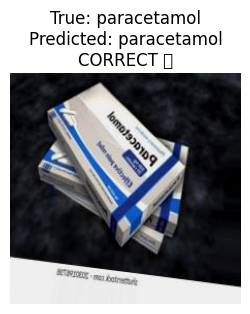

True Drug: paracetamol
Predicted: paracetamol
Confidence: 99.84 %
Status: CORRECT ✅
------------------------------


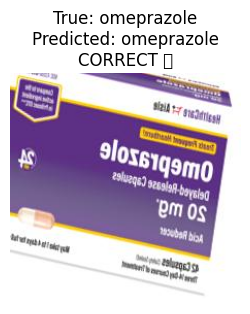

True Drug: omeprazole
Predicted: omeprazole
Confidence: 99.85 %
Status: CORRECT ✅
------------------------------


In [17]:
tested = set()

for i in range(len(y_test)):
    true_class = int(y_test[i])

    if true_class not in tested:
        prediction = model.predict([
            np.expand_dims(X_img_test[i], axis=0),
            np.expand_dims(X_txt_test[i], axis=0)
        ], verbose=0)

        predicted_class = int(np.argmax(prediction))
        confidence = float(np.max(prediction))

        true_drug = label_classes[str(true_class)]
        predicted_drug = label_classes[str(predicted_class)]

        status = "CORRECT ✅" if true_drug == predicted_drug else "WRONG ❌"

        plt.figure(figsize=(3, 3))
        plt.imshow(X_img_test[i])
        plt.title(f"True: {true_drug}\nPredicted: {predicted_drug}\n{status}")
        plt.axis("off")
        plt.show()

        print("True Drug:", true_drug)
        print("Predicted:", predicted_drug)
        print("Confidence:", round(confidence * 100, 2), "%")
        print("Status:", status)
        print("-" * 30)

        tested.add(true_class)

    if len(tested) == num_classes:
        break


## 18. Count Correct and Wrong Test Predictions

In [18]:
correct = np.sum(y_pred == y_test)
wrong = np.sum(y_pred != y_test)
total = len(y_test)

print("Total Test Samples:", total)
print("Correct Predictions:", correct)
print("Wrong Predictions:", wrong)
print("Accuracy:", correct / total)


Total Test Samples: 80
Correct Predictions: 72
Wrong Predictions: 8
Accuracy: 0.9


## 19. Load Safety Dataset

In [19]:
with open("/content/safety_dataset.json", "r") as f:
    safety_data = json.load(f)

print(safety_data[:2])


[{'input': 'drug: paracetamol; condition: pregnancy', 'output': 'safety: safe; recommendation: commonly used; alternative: none'}, {'input': 'drug: paracetamol; condition: liver disease', 'output': 'safety: warning; recommendation: use low dose; alternative: consult doctor'}]


In [20]:
def check_safety(drug_name, condition):
    drug_name = drug_name.lower().strip()
    condition = condition.lower().strip()

    for item in safety_data:
        input_text = item["input"].lower()

        if f"drug: {drug_name}" in input_text and f"condition: {condition}" in input_text:
            return item["output"]

    return "No safety information found."


In [21]:
drug = "ibuprofen"
condition = "stomach ulcer"

result = check_safety(drug, condition)
print(result)


safety: dangerous; recommendation: do not use; alternative: paracetamol


## 20. Load Interaction Dataset

In [22]:
with open("/content/interaction_dataset.json", "r") as f:
    interaction_data = json.load(f)

print(interaction_data[:2])


[{'input': 'drug1: ibuprofen; drug2: aspirin', 'output': 'safety: dangerous; recommendation: do not combine; alternative: paracetamol'}, {'input': 'drug1: paracetamol; drug2: ibuprofen', 'output': 'safety: safe; recommendation: can be used together carefully; alternative: none'}]


In [23]:
def check_interaction(drug1, drug2):
    drug1 = drug1.lower().strip()
    drug2 = drug2.lower().strip()

    for item in interaction_data:
        input_text = item["input"].lower()

        case1 = f"drug1: {drug1}" in input_text and f"drug2: {drug2}" in input_text
        case2 = f"drug1: {drug2}" in input_text and f"drug2: {drug1}" in input_text

        if case1 or case2:
            return item["output"]

    return "No interaction information found."


In [24]:
drug1 = "ibuprofen"
drug2 = "aspirin"

result = check_interaction(drug1, drug2)
print(result)


safety: dangerous; recommendation: do not combine; alternative: paracetamol


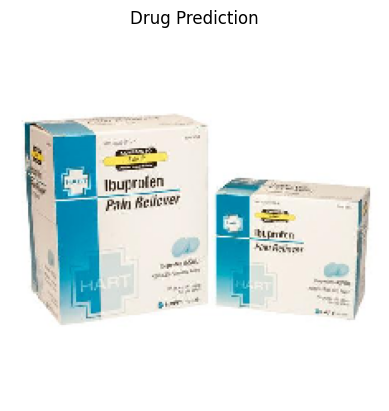

Predicted: ibuprofen
Actual: ibuprofen
Prediction Probabilities:
[[5.0531025e-03 1.5607356e-01 8.3394086e-01 1.5752545e-03 7.0344562e-05
  3.2869279e-03]]


In [27]:
index = 8

sample_image = X_img_test[index]
sample_text = X_txt_test[index]

prediction = model.predict([
    np.expand_dims(sample_image, axis=0),
    np.expand_dims(sample_text, axis=0)
], verbose=0)

predicted_class = int(np.argmax(prediction))
actual_class = int(y_test[index])

plt.imshow(sample_image)
plt.title("Drug Prediction")
plt.axis("off")
plt.show()

print("Predicted:", label_classes[str(predicted_class)])
print("Actual:", label_classes[str(actual_class)])
print("Prediction Probabilities:")
print(prediction)

In [28]:
for i in range(5):

    prediction = model.predict([
        np.expand_dims(X_img_test[i], axis=0),
        np.expand_dims(X_txt_test[i], axis=0)
    ], verbose=0)

    predicted_class = int(np.argmax(prediction))

    print("Sample", i)
    print("Predicted:", label_classes[str(predicted_class)])
    print("Actual:", label_classes[str(int(y_test[i]))])
    print("-" * 30)

Sample 0
Predicted: ibuprofen
Actual: ibuprofen
------------------------------
Sample 1
Predicted: ibuprofen
Actual: ibuprofen
------------------------------
Sample 2
Predicted: aspirin
Actual: aspirin
------------------------------
Sample 3
Predicted: amoxicillin
Actual: amoxicillin
------------------------------
Sample 4
Predicted: insulin
Actual: insulin
------------------------------


In [29]:
print(check_safety("paracetamol", "pregnancy"))

safety: safe; recommendation: commonly used; alternative: none


In [30]:
print(check_safety("ibuprofen", "high blood pressure"))

safety: warning; recommendation: avoid long-term use; alternative: paracetamol


In [31]:
print(check_interaction("paracetamol", "ibuprofen"))

safety: safe; recommendation: can be used together carefully; alternative: none


In [32]:
print(check_interaction("aspirin", "omeprazole"))

safety: safe; recommendation: reduces stomach irritation; alternative: none


In [34]:
drug = input("Enter Drug: ")
condition = input("Enter Condition: ")

print(check_safety(drug, condition))

Enter Drug: insulin
Enter Condition:  diabetes
safety: safe; recommendation: necessary medication; alternative: none


Enter Drug Name: amoxicillin


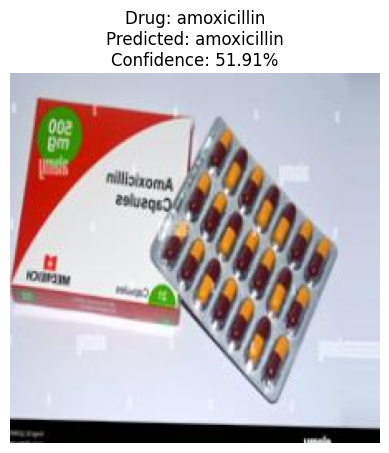

Actual: amoxicillin
Predicted: amoxicillin
Confidence: 51.91 %


In [35]:
import random

drug_name = input("Enter Drug Name: ").lower().strip()

class_index = None

for key, value in label_classes.items():
    if value == drug_name:
        class_index = int(key)
        break

if class_index is None:
    print("Drug not found.")
    print("Available drugs:", list(label_classes.values()))

else:
    indices = np.where(y_test == class_index)[0]

    random_index = random.choice(indices)

    sample_image = X_img_test[random_index]
    sample_text = X_txt_test[random_index]

    prediction = model.predict([
        np.expand_dims(sample_image, axis=0),
        np.expand_dims(sample_text, axis=0)
    ], verbose=0)

    predicted_class = int(np.argmax(prediction))
    confidence = float(np.max(prediction))

    plt.imshow(sample_image)
    plt.title(
        f"Drug: {drug_name}\nPredicted: {label_classes[str(predicted_class)]}\nConfidence: {confidence*100:.2f}%"
    )
    plt.axis("off")
    plt.show()

    print("Actual:", drug_name)
    print("Predicted:", label_classes[str(predicted_class)])
    print("Confidence:", round(confidence * 100, 2), "%")

Enter Drug Name: ibuprofen


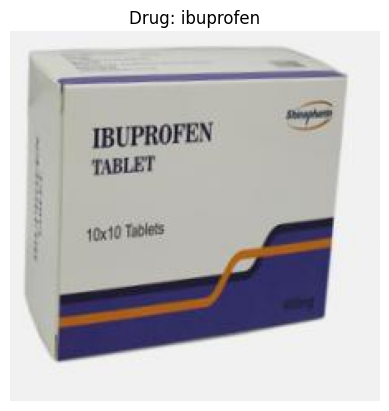

In [36]:
import matplotlib.pyplot as plt
import random

# Enter drug name
drug_name = input("Enter Drug Name: ").lower()

# Find class index
class_index = None

for key, value in label_classes.items():
    if value == drug_name:
        class_index = int(key)
        break

if class_index is not None:

    # Get indices of this class
    indices = np.where(y_test == class_index)[0]

    # Random sample
    random_index = random.choice(indices)

    # Get image
    image = X_img_test[random_index]

    # Show image
    plt.imshow(image)
    plt.title(f"Drug: {drug_name}")
    plt.axis('off')
    plt.show()

else:
    print("Drug not found")

Enter Drug Name: ibuprofen


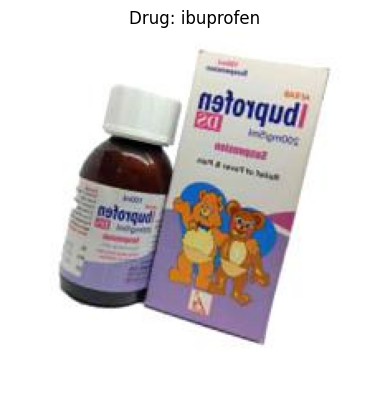

In [37]:
import matplotlib.pyplot as plt
import random

# Enter drug name
drug_name = input("Enter Drug Name: ").lower()

# Find class index
class_index = None

for key, value in label_classes.items():
    if value == drug_name:
        class_index = int(key)
        break

if class_index is not None:

    # Get indices of this class
    indices = np.where(y_test == class_index)[0]

    # Random sample
    random_index = random.choice(indices)

    # Get image
    image = X_img_test[random_index]

    # Show image
    plt.imshow(image)
    plt.title(f"Drug: {drug_name}")
    plt.axis('off')
    plt.show()

else:
    print("Drug not found")

Enter Drug Name: insulin


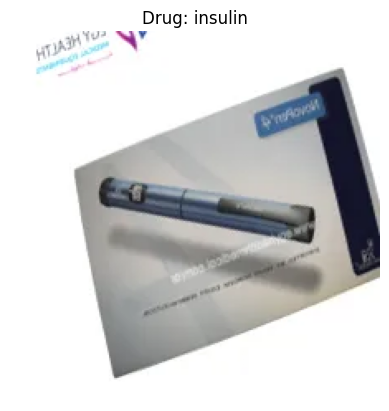

In [38]:
import matplotlib.pyplot as plt
import random

# Enter drug name
drug_name = input("Enter Drug Name: ").lower()

# Find class index
class_index = None

for key, value in label_classes.items():
    if value == drug_name:
        class_index = int(key)
        break

if class_index is not None:

    # Get indices of this class
    indices = np.where(y_test == class_index)[0]

    # Random sample
    random_index = random.choice(indices)

    # Get image
    image = X_img_test[random_index]

    # Show image
    plt.imshow(image)
    plt.title(f"Drug: {drug_name}")
    plt.axis('off')
    plt.show()

else:
    print("Drug not found")


Enter Drug Name: omeprazole


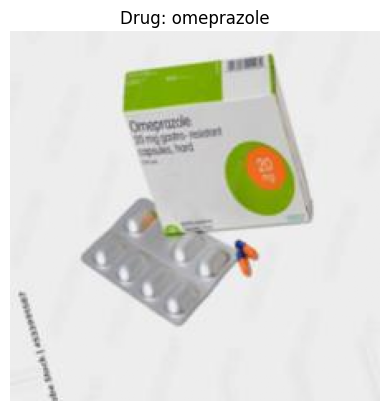

In [39]:
import matplotlib.pyplot as plt
import random

# Enter drug name
drug_name = input("Enter Drug Name: ").lower()

# Find class index
class_index = None

for key, value in label_classes.items():
    if value == drug_name:
        class_index = int(key)
        break

if class_index is not None:

    # Get indices of this class
    indices = np.where(y_test == class_index)[0]

    # Random sample
    random_index = random.choice(indices)

    # Get image
    image = X_img_test[random_index]

    # Show image
    plt.imshow(image)
    plt.title(f"Drug: {drug_name}")
    plt.axis('off')
    plt.show()

else:
    print("Drug not found")

Enter Drug Name: paracetamol


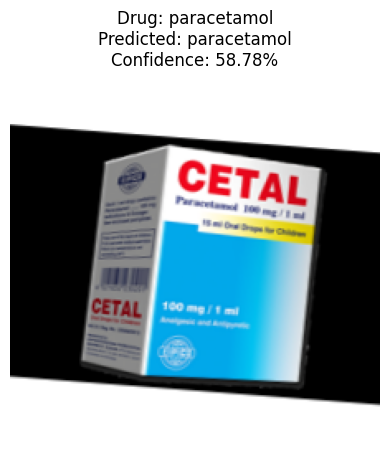

Actual: paracetamol
Predicted: paracetamol
Confidence: 58.78 %


In [40]:
import random

drug_name = input("Enter Drug Name: ").lower().strip()

class_index = None

for key, value in label_classes.items():
    if value == drug_name:
        class_index = int(key)
        break

if class_index is None:
    print("Drug not found.")
    print("Available drugs:", list(label_classes.values()))

else:
    indices = np.where(y_test == class_index)[0]

    random_index = random.choice(indices)

    sample_image = X_img_test[random_index]
    sample_text = X_txt_test[random_index]

    prediction = model.predict([
        np.expand_dims(sample_image, axis=0),
        np.expand_dims(sample_text, axis=0)
    ], verbose=0)

    predicted_class = int(np.argmax(prediction))
    confidence = float(np.max(prediction))

    plt.imshow(sample_image)
    plt.title(
        f"Drug: {drug_name}\nPredicted: {label_classes[str(predicted_class)]}\nConfidence: {confidence*100:.2f}%"
    )
    plt.axis("off")
    plt.show()

    print("Actual:", drug_name)
    print("Predicted:", label_classes[str(predicted_class)])
    print("Confidence:", round(confidence * 100, 2), "%")

Enter Drug Name: paracetamol


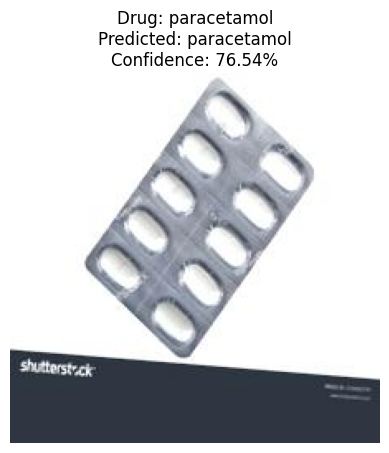

Actual: paracetamol
Predicted: paracetamol
Confidence: 76.54 %


In [41]:
import random

drug_name = input("Enter Drug Name: ").lower().strip()

class_index = None

for key, value in label_classes.items():
    if value == drug_name:
        class_index = int(key)
        break

if class_index is None:
    print("Drug not found.")
    print("Available drugs:", list(label_classes.values()))

else:
    indices = np.where(y_test == class_index)[0]

    random_index = random.choice(indices)

    sample_image = X_img_test[random_index]
    sample_text = X_txt_test[random_index]

    prediction = model.predict([
        np.expand_dims(sample_image, axis=0),
        np.expand_dims(sample_text, axis=0)
    ], verbose=0)

    predicted_class = int(np.argmax(prediction))
    confidence = float(np.max(prediction))

    plt.imshow(sample_image)
    plt.title(
        f"Drug: {drug_name}\nPredicted: {label_classes[str(predicted_class)]}\nConfidence: {confidence*100:.2f}%"
    )
    plt.axis("off")
    plt.show()

    print("Actual:", drug_name)
    print("Predicted:", label_classes[str(predicted_class)])
    print("Confidence:", round(confidence * 100, 2), "%")

Enter Drug Name: paracetamol


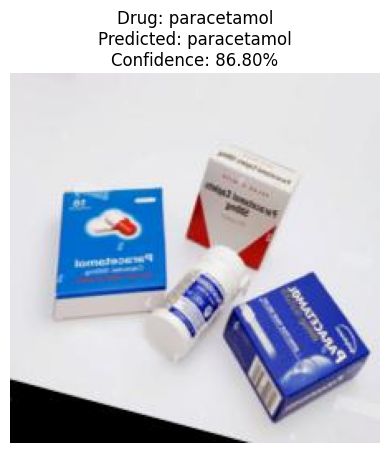

Actual: paracetamol
Predicted: paracetamol
Confidence: 86.8 %


In [45]:
import random

drug_name = input("Enter Drug Name: ").lower().strip()

class_index = None

for key, value in label_classes.items():
    if value == drug_name:
        class_index = int(key)
        break

if class_index is None:
    print("Drug not found.")
    print("Available drugs:", list(label_classes.values()))

else:
    indices = np.where(y_test == class_index)[0]

    random_index = random.choice(indices)

    sample_image = X_img_test[random_index]
    sample_text = X_txt_test[random_index]

    prediction = model.predict([
        np.expand_dims(sample_image, axis=0),
        np.expand_dims(sample_text, axis=0)
    ], verbose=0)

    predicted_class = int(np.argmax(prediction))
    confidence = float(np.max(prediction))

    plt.imshow(sample_image)
    plt.title(
        f"Drug: {drug_name}\nPredicted: {label_classes[str(predicted_class)]}\nConfidence: {confidence*100:.2f}%"
    )
    plt.axis("off")
    plt.show()

    print("Actual:", drug_name)
    print("Predicted:", label_classes[str(predicted_class)])
    print("Confidence:", round(confidence * 100, 2), "%")


Enter Drug Name: paracetamol


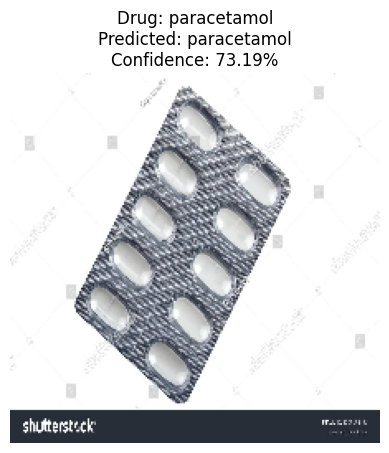

Actual: paracetamol
Predicted: paracetamol
Confidence: 73.19 %


In [46]:
import random

drug_name = input("Enter Drug Name: ").lower().strip()

class_index = None

for key, value in label_classes.items():
    if value == drug_name:
        class_index = int(key)
        break

if class_index is None:
    print("Drug not found.")
    print("Available drugs:", list(label_classes.values()))

else:
    indices = np.where(y_test == class_index)[0]

    random_index = random.choice(indices)

    sample_image = X_img_test[random_index]
    sample_text = X_txt_test[random_index]

    prediction = model.predict([
        np.expand_dims(sample_image, axis=0),
        np.expand_dims(sample_text, axis=0)
    ], verbose=0)

    predicted_class = int(np.argmax(prediction))
    confidence = float(np.max(prediction))

    plt.imshow(sample_image)
    plt.title(
        f"Drug: {drug_name}\nPredicted: {label_classes[str(predicted_class)]}\nConfidence: {confidence*100:.2f}%"
    )
    plt.axis("off")
    plt.show()

    print("Actual:", drug_name)
    print("Predicted:", label_classes[str(predicted_class)])
    print("Confidence:", round(confidence * 100, 2), "%")


In [58]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-05-12 223555.png to Screenshot 2026-05-12 223555.png


In [59]:
user_text = input("Enter drug text/context: ")

Enter drug text/context: نط


In [60]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.sequence import pad_sequences

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array.astype("float32")
img_array = np.expand_dims(img_array, axis=0)

text_seq = tokenizer.texts_to_sequences([user_text])
text_seq = pad_sequences(text_seq, maxlen=max_len).astype("int32")

In [62]:
prediction = model.predict([img_array, text_seq], verbose=0)

predicted_class = int(np.argmax(prediction))
confidence = float(np.max(prediction))

predicted_drug = label_classes[str(predicted_class)]

print("Predicted Drug:", predicted_drug)
print("Confidence:", round(confidence * 100, 2), "%")

Predicted Drug: aspirin
Confidence: 61.5 %


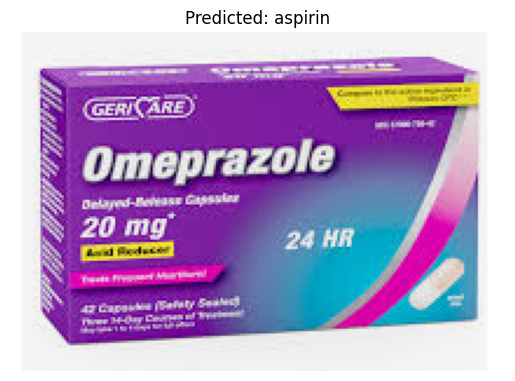

In [63]:
plt.imshow(image.load_img(img_path))
plt.title(f"Predicted: {predicted_drug}")
plt.axis("off")
plt.show()

## 21. Full Pharmacy Prediction System

In [25]:
def full_pharmacy_prediction(sample_index, user_condition, second_drug=None):
    prediction = model.predict([
        np.expand_dims(X_img_test[sample_index], axis=0),
        np.expand_dims(X_txt_test[sample_index], axis=0)
    ], verbose=0)

    predicted_class = int(np.argmax(prediction))
    confidence = float(np.max(prediction))

    predicted_drug = label_classes[str(predicted_class)]
    true_drug = label_classes[str(int(y_test[sample_index]))]

    safety_result = check_safety(predicted_drug, user_condition)

    if second_drug is not None and second_drug.strip() != "":
        interaction_result = check_interaction(predicted_drug, second_drug)
    else:
        interaction_result = "No second drug entered."

    result = {
        "Predicted Drug": predicted_drug,
        "True Drug": true_drug,
        "Confidence": f"{confidence * 100:.2f}%",
        "User Condition": user_condition,
        "Safety Result": safety_result,
        "Second Drug": second_drug,
        "Interaction Result": interaction_result
    }

    for key, value in result.items():
        print(f"{key}: {value}")

    return result


In [26]:
full_pharmacy_prediction(
    sample_index=0,
    user_condition="stomach ulcer",
    second_drug="aspirin"
)


Predicted Drug: ibuprofen
True Drug: ibuprofen
Confidence: 83.90%
User Condition: stomach ulcer
Safety Result: safety: dangerous; recommendation: do not use; alternative: paracetamol
Second Drug: aspirin
Interaction Result: safety: dangerous; recommendation: do not combine; alternative: paracetamol


{'Predicted Drug': 'ibuprofen',
 'True Drug': 'ibuprofen',
 'Confidence': '83.90%',
 'User Condition': 'stomach ulcer',
 'Safety Result': 'safety: dangerous; recommendation: do not use; alternative: paracetamol',
 'Second Drug': 'aspirin',
 'Interaction Result': 'safety: dangerous; recommendation: do not combine; alternative: paracetamol'}

## Final Notes

This notebook follows the same workflow as the ResNet50 + LSTM notebook, but the image branch uses **MobileNetV2**.

- ResNet50 was replaced with MobileNetV2.
- LSTM text branch is kept.
- Image and text features are fused.
- Safety and interaction JSON files are connected after prediction.


In [64]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [65]:
model.save("/content/drive/MyDrive/Safia_MobileNetV2_LSTM_Model.keras")
print("Model saved to Drive ✅")

Model saved to Drive ✅


In [66]:
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/Safia_MobileNetV2_LSTM_Model.keras")

with open("/content/drive/MyDrive/Safia_label_classes.json", "w") as f:
    json.dump(label_classes, f)

print("Model and class labels saved successfully ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model and class labels saved successfully ✅


In [67]:
import json

model.save("/content/drive/MyDrive/Safia_MobileNetV2_LSTM_Model.keras")

with open("/content/drive/MyDrive/Safia_label_classes.json", "w") as f:
    json.dump(label_classes, f)

print("Model and classes saved ✅")

Model and classes saved ✅
